# Decision Tree Assignment: Regression and Classification

**Name:** Shubham Ghosh Roy

**Objective:** Implement Decision Tree Regression and Decision Tree Classification using `sklearn`, evaluate both models, apply pruning/hyperparameter tuning, and interpret results from EDA, model metrics, and tree behavior.

**Datasets used:**
- `Movie_regression.csv` — regression target: `Collection`
- `Movie_classification.csv` — classification target: `Start_Tech_Oscar`

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)

%matplotlib inline
RANDOM_STATE = 42

## 1. Import the Datasets

In [31]:
reg_df = pd.read_csv("Movie_regression.csv")
clf_df = pd.read_csv("Movie_classification.csv")

display(reg_df.head())

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400


In [32]:
display(clf_df.head())

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1


## 2. Identify the Target Columns

- **Regression target:** `Collection` (continuous — total box-office collection of the movie)
- **Classification target:** `Start_Tech_Oscar` (binary — whether the movie's startup-tech received an Oscar, 0/1)

## 3. Exploratory Data Analysis (EDA)

In [37]:
print("REGRESSION DATA")
print("Shape:", reg_df.shape)
print("Columns:", list(reg_df.columns))
print()
print(reg_df.dtypes)

REGRESSION DATA
Shape: (506, 18)
Columns: ['Marketing expense', 'Production expense', 'Multiplex coverage', 'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating', 'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views', '3D_available', 'Time_taken', 'Twitter_hastags', 'Genre', 'Avg_age_actors', 'Num_multiplex', 'Collection']

Marketing expense      float64
Production expense     float64
Multiplex coverage     float64
Budget                 float64
Movie_length           float64
Lead_ Actor_Rating     float64
Lead_Actress_rating    float64
Director_rating        float64
Producer_rating        float64
Critic_rating          float64
Trailer_views            int64
3D_available               str
Time_taken             float64
Twitter_hastags        float64
Genre                      str
Avg_age_actors           int64
Num_multiplex            int64
Collection               int64
dtype: object


In [38]:
print("CLASSIFICATION DATA")
print("Shape:", clf_df.shape)
print("Columns:", list(clf_df.columns))
print()
print(clf_df.dtypes)

CLASSIFICATION DATA
Shape: (506, 19)
Columns: ['Marketing expense', 'Production expense', 'Multiplex coverage', 'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating', 'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views', '3D_available', 'Time_taken', 'Twitter_hastags', 'Genre', 'Avg_age_actors', 'Num_multiplex', 'Collection', 'Start_Tech_Oscar']

Marketing expense      float64
Production expense     float64
Multiplex coverage     float64
Budget                 float64
Movie_length           float64
Lead_ Actor_Rating     float64
Lead_Actress_rating    float64
Director_rating        float64
Producer_rating        float64
Critic_rating          float64
Trailer_views            int64
3D_available               str
Time_taken             float64
Twitter_hastags        float64
Genre                      str
Avg_age_actors           int64
Num_multiplex            int64
Collection               int64
Start_Tech_Oscar         int64
dtype: object


In [39]:
print("Missing values — Regression data:")
print(reg_df.isnull().sum()[reg_df.isnull().sum() > 0])
print("\nMissing values — Classification data:")
print(clf_df.isnull().sum()[clf_df.isnull().sum() > 0])

Missing values — Regression data:
Time_taken    12
dtype: int64

Missing values — Classification data:
Time_taken    12
dtype: int64


In [41]:
print("Duplicate rows — Regression data:", reg_df.duplicated().sum())
print("Duplicate rows — Classification data:", clf_df.duplicated().sum())

Duplicate rows — Regression data: 0
Duplicate rows — Classification data: 0


/var/folders/td/msswlxh906j1zlnb7wzz8pr40000gn/T/ipykernel_8827/668801088.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Start_Tech_Oscar", data=clf_df, ax=axes[1], palette=["#DD8452", "#55A868"])


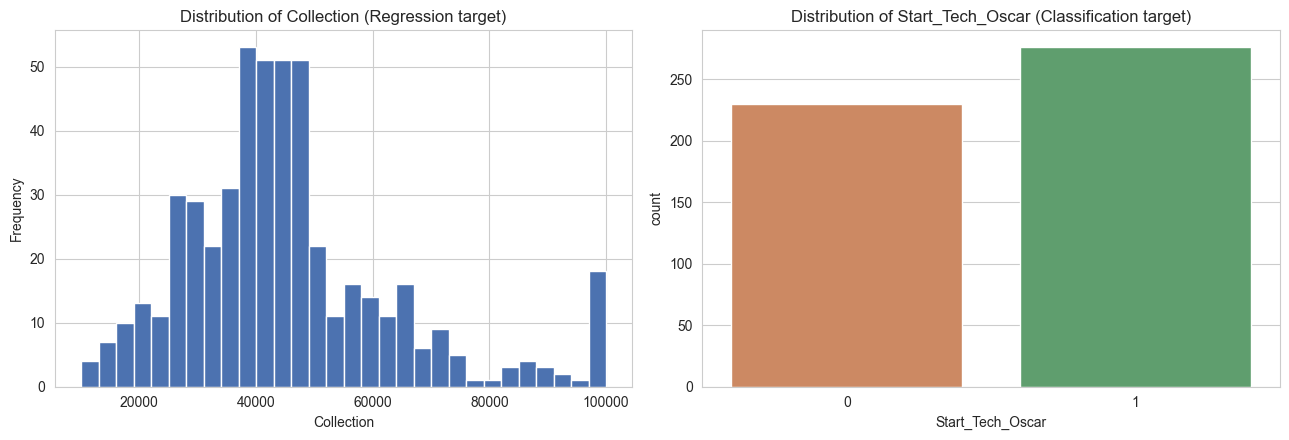

Start_Tech_Oscar
1    0.545455
0    0.454545
Name: proportion, dtype: float64


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(reg_df["Collection"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Collection (Regression target)")
axes[0].set_xlabel("Collection")
axes[0].set_ylabel("Frequency")

sns.countplot(x="Start_Tech_Oscar", data=clf_df, ax=axes[1], palette=["#DD8452", "#55A868"])
axes[1].set_title("Distribution of Start_Tech_Oscar (Classification target)")
axes[1].set_xlabel("Start_Tech_Oscar")

plt.tight_layout()
plt.show()

print(clf_df["Start_Tech_Oscar"].value_counts(normalize=True))

In [43]:
print("Regression data — summary statistics")
display(reg_df.describe())

print("\nClassification data — summary statistics")
display(clf_df.describe())

Regression data — summary statistics


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000,506.000000,506.000000,506.000000
mean,92.270471,77.273557,0.445305,34911.144022,142.074901,8.014002,8.185613,8.019664,8.190514,7.810870,449860.715415,157.391498,260.832095,39.181818,545.043478,45057.707510
std,172.030902,13.720706,0.115878,3903.038232,28.148861,1.054266,1.054290,1.059899,1.049601,0.659699,68917.763145,31.295161,104.779133,12.513697,106.332889,18364.351764
min,20.126400,55.920000,0.129000,19781.355000,76.400000,3.840000,4.035000,3.840000,4.030000,6.600000,212912.000000,0.000000,201.152000,3.000000,333.000000,10000.000000
25%,21.640900,65.380000,0.376000,32693.952500,118.525000,7.316250,7.503750,7.296250,7.507500,7.200000,409128.000000,132.300000,223.796000,28.000000,465.000000,34050.000000
50%,25.130200,74.380000,0.462000,34488.217500,151.000000,8.307500,8.495000,8.312500,8.465000,7.960000,462460.000000,160.000000,254.400000,39.000000,535.500000,42400.000000
75%,93.541650,91.200000,0.551000,36793.542500,167.575000,8.865000,9.030000,8.883750,9.030000,8.260000,500247.500000,181.890000,283.416000,50.000000,614.750000,50000.000000
max,1799.524000,110.480000,0.615000,48772.900000,173.500000,9.435000,9.540000,9.425000,9.635000,9.400000,567784.000000,217.520000,2022.400000,60.000000,868.000000,100000.000000



Classification data — summary statistics


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,92.270471,77.273557,0.445305,34911.144022,142.074901,8.014002,8.185613,8.019664,8.190514,7.810870,449860.715415,157.391498,260.832095,39.181818,545.043478,45057.707510,0.545455
std,172.030902,13.720706,0.115878,3903.038232,28.148861,1.054266,1.054290,1.059899,1.049601,0.659699,68917.763145,31.295161,104.779133,12.513697,106.332889,18364.351764,0.498422
min,20.126400,55.920000,0.129000,19781.355000,76.400000,3.840000,4.035000,3.840000,4.030000,6.600000,212912.000000,0.000000,201.152000,3.000000,333.000000,10000.000000,0.000000
25%,21.640900,65.380000,0.376000,32693.952500,118.525000,7.316250,7.503750,7.296250,7.507500,7.200000,409128.000000,132.300000,223.796000,28.000000,465.000000,34050.000000,0.000000
50%,25.130200,74.380000,0.462000,34488.217500,151.000000,8.307500,8.495000,8.312500,8.465000,7.960000,462460.000000,160.000000,254.400000,39.000000,535.500000,42400.000000,1.000000
75%,93.541650,91.200000,0.551000,36793.542500,167.575000,8.865000,9.030000,8.883750,9.030000,8.260000,500247.500000,181.890000,283.416000,50.000000,614.750000,50000.000000,1.000000
max,1799.524000,110.480000,0.615000,48772.900000,173.500000,9.435000,9.540000,9.425000,9.635000,9.400000,567784.000000,217.520000,2022.400000,60.000000,868.000000,100000.000000,1.000000


Correlation of numeric features with Collection (regression target):
Collection             1.000000
Trailer_views          0.720119
Budget                 0.696304
Multiplex coverage     0.429300
Critic_rating          0.341288
Time_taken             0.111092
Twitter_hastags        0.023122
Avg_age_actors        -0.047426
Director_rating       -0.246650
Producer_rating       -0.248200
Lead_Actress_rating   -0.249459
Lead_ Actor_Rating    -0.251355
Movie_length          -0.377999
Marketing expense     -0.389582
Num_multiplex         -0.391729
Production expense    -0.484754
Name: Collection, dtype: float64


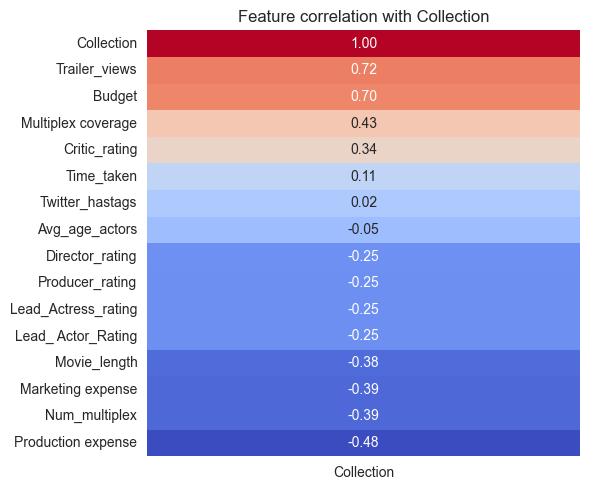

In [8]:
corr_reg = reg_df.select_dtypes(include=[np.number]).corr()["Collection"].sort_values(ascending=False)
print("Correlation of numeric features with Collection (regression target):")
print(corr_reg)

plt.figure(figsize=(6, 5))
sns.heatmap(reg_df.select_dtypes(include=[np.number]).corr()[["Collection"]].sort_values("Collection", ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Feature correlation with Collection")
plt.tight_layout()
plt.show()

Correlation of numeric features with Start_Tech_Oscar (classification target):
Start_Tech_Oscar       1.000000
Collection             0.154698
Twitter_hastags        0.077333
Avg_age_actors         0.040581
Movie_length           0.016291
Critic_rating         -0.001084
Multiplex coverage    -0.004017
Num_multiplex         -0.004857
Marketing expense     -0.013417
Production expense    -0.024404
Budget                -0.027148
Lead_ Actor_Rating    -0.035309
Director_rating       -0.035768
Lead_Actress_rating   -0.040356
Producer_rating       -0.043612
Time_taken            -0.064536
Trailer_views         -0.075783
Name: Start_Tech_Oscar, dtype: float64


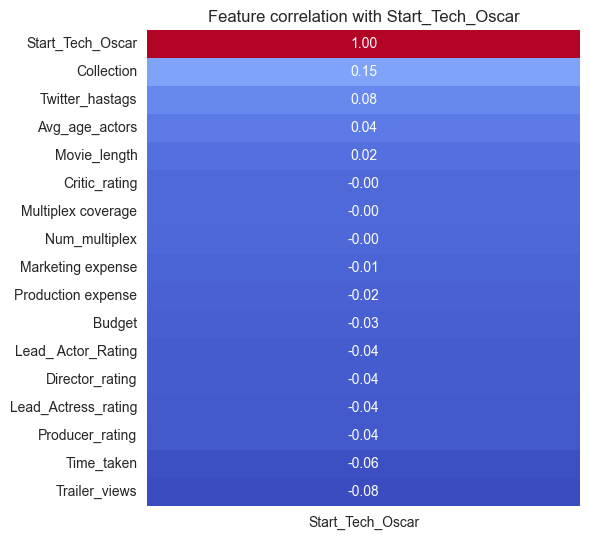

In [9]:
corr_clf = clf_df.select_dtypes(include=[np.number]).corr()["Start_Tech_Oscar"].sort_values(ascending=False)
print("Correlation of numeric features with Start_Tech_Oscar (classification target):")
print(corr_clf)

plt.figure(figsize=(6, 5.5))
sns.heatmap(clf_df.select_dtypes(include=[np.number]).corr()[["Start_Tech_Oscar"]].sort_values("Start_Tech_Oscar", ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Feature correlation with Start_Tech_Oscar")
plt.tight_layout()
plt.show()

**Observation:** For regression, `Trailer_views` (≈0.72) and `Budget` (≈0.70) are the strongest positive correlates of `Collection`, while `Production expense` (≈‑0.48) and `Num_multiplex` (≈‑0.39) are the strongest negative correlates — this already hints at which features the tree is likely to split on first.

For classification, correlations with `Start_Tech_Oscar` are all weak (the strongest, `Collection` itself, is only ≈0.15). This is an early warning sign that **no single feature is strongly predictive** of the classification target, so we should expect the classifier to perform only modestly better than a random/majority-class guess, and to be more prone to overfitting noise.

/var/folders/td/msswlxh906j1zlnb7wzz8pr40000gn/T/ipykernel_8827/2664867635.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Genre", y="Collection", data=reg_df, ax=axes[1], palette="Set2")


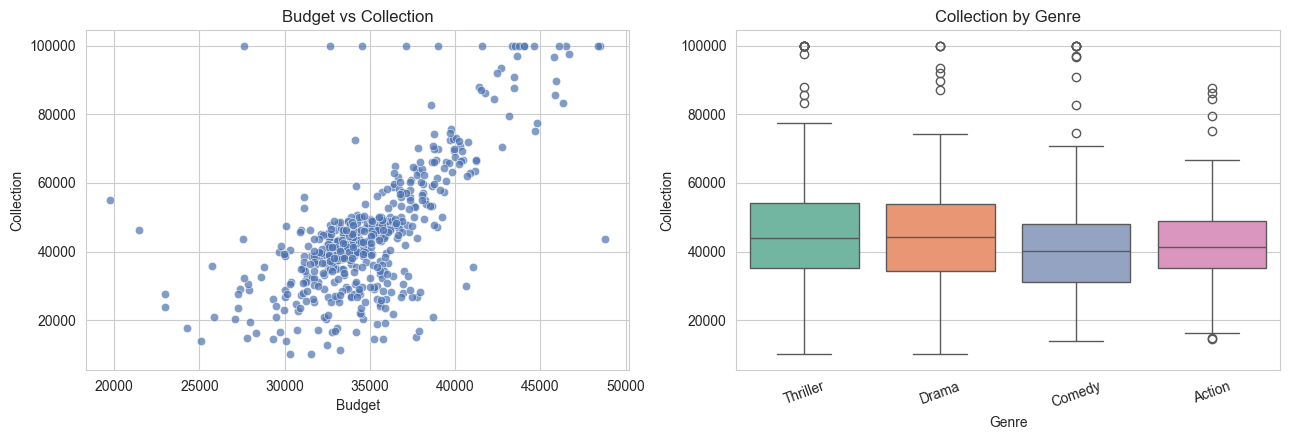

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(x="Budget", y="Collection", data=reg_df, ax=axes[0], color="#4C72B0", alpha=0.7)
axes[0].set_title("Budget vs Collection")

sns.boxplot(x="Genre", y="Collection", data=reg_df, ax=axes[1], palette="Set2")
axes[1].set_title("Collection by Genre")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

/var/folders/td/msswlxh906j1zlnb7wzz8pr40000gn/T/ipykernel_8827/532303551.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Start_Tech_Oscar", y="Collection", data=clf_df, ax=axes[1], palette="Set2")


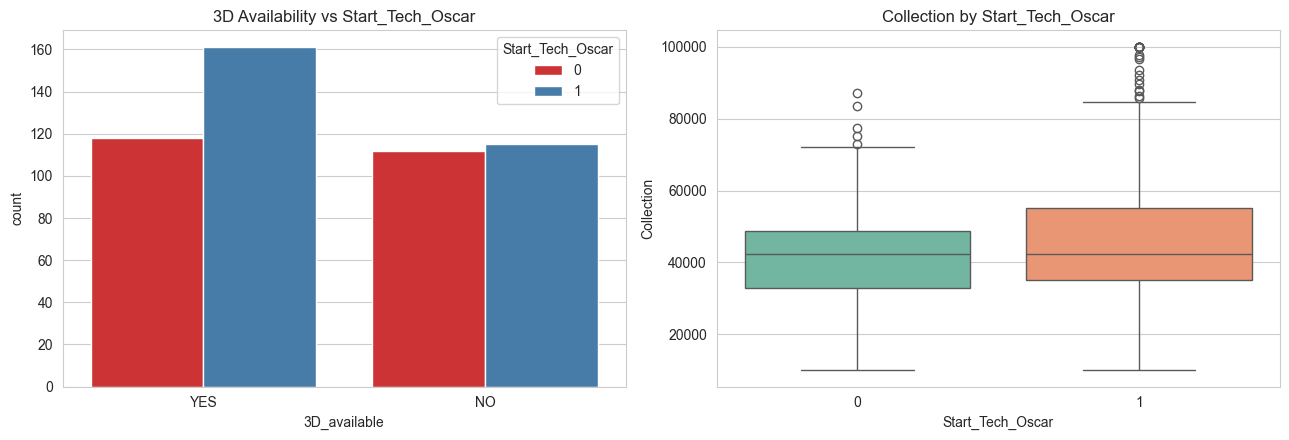

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(x="3D_available", hue="Start_Tech_Oscar", data=clf_df, ax=axes[0], palette="Set1")
axes[0].set_title("3D Availability vs Start_Tech_Oscar")

sns.boxplot(x="Start_Tech_Oscar", y="Collection", data=clf_df, ax=axes[1], palette="Set2")
axes[1].set_title("Collection by Start_Tech_Oscar")

plt.tight_layout()
plt.show()

**Observation:** `Collection` increases roughly linearly with `Budget`, confirming it as a strong regression predictor. `Genre` shows visible differences in median collection across categories (Thriller/Action tend higher), so it's a useful categorical feature once encoded. For classification, `3D_available` and `Collection` show only mild visual separation between the two `Start_Tech_Oscar` classes, reinforcing the earlier correlation finding that this is a harder, weakly-separable classification problem.

## 4. Separate Features and Target

In [12]:
Xr = reg_df.drop(columns=["Collection"])
yr = reg_df["Collection"]

Xc = clf_df.drop(columns=["Start_Tech_Oscar"])
yc = clf_df["Start_Tech_Oscar"]

print("Xr shape:", Xr.shape, "| yr shape:", yr.shape)
print("Xc shape:", Xc.shape, "| yc shape:", yc.shape)

Xr shape: (506, 17) | yr shape: (506,)
Xc shape: (506, 18) | yc shape: (506,)


## 5. Preprocessing

In [13]:
# Time_taken has 12 missing values in both feature sets — impute with the median
# (median is preferred over mean here since it's robust to any skew/outliers in Time_taken)
Xr["Time_taken"] = Xr["Time_taken"].fillna(Xr["Time_taken"].median())
Xc["Time_taken"] = Xc["Time_taken"].fillna(Xc["Time_taken"].median())

print("Remaining missing values in Xr:", Xr.isnull().sum().sum())
print("Remaining missing values in Xc:", Xc.isnull().sum().sum())

Remaining missing values in Xr: 0
Remaining missing values in Xc: 0


In [44]:
Xr = pd.get_dummies(Xr, drop_first=True)
Xc = pd.get_dummies(Xc, drop_first=True)

print("Xr columns after encoding:")
print(list(Xr.columns))
print()
print("\nXc columns after encoding:")
print(list(Xc.columns))

Xr columns after encoding:
['Marketing expense', 'Production expense', 'Multiplex coverage', 'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating', 'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views', 'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex', '3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']


Xc columns after encoding:
['Marketing expense', 'Production expense', 'Multiplex coverage', 'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating', 'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views', 'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex', 'Collection', '3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']


## 6. Train-Test Split (80:20)

In [16]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

print("Regression  -> train:", Xr_train.shape, " test:", Xr_test.shape)
print("Classification -> train:", Xc_train.shape, " test:", Xc_test.shape)
print("\nTrain class balance:\n", yc_train.value_counts(normalize=True))
print("\nTest class balance:\n", yc_test.value_counts(normalize=True))

Regression  -> train: (404, 19)  test: (102, 19)
Classification -> train: (404, 20)  test: (102, 20)

Train class balance:
 Start_Tech_Oscar
1    0.544554
0    0.455446
Name: proportion, dtype: float64

Test class balance:
 Start_Tech_Oscar
1    0.54902
0    0.45098
Name: proportion, dtype: float64


## 7. Train Baseline Models (Unpruned)

In [17]:
reg_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
clf_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

reg_model.fit(Xr_train, yr_train)
clf_model.fit(Xc_train, yc_train)

reg_pred = reg_model.predict(Xr_test)
clf_pred = clf_model.predict(Xc_test)

print("Baseline regressor depth:", reg_model.get_depth(), "| leaves:", reg_model.get_n_leaves())
print("Baseline classifier depth:", clf_model.get_depth(), "| leaves:", clf_model.get_n_leaves())

Baseline regressor depth: 20 | leaves: 379
Baseline classifier depth: 14 | leaves: 76


## 8. Evaluate Initial Unpruned Models

### Regression Metrics

In [18]:
mae = mean_absolute_error(yr_test, reg_pred)
mse = mean_squared_error(yr_test, reg_pred)
rmse = mse ** 0.5
r2_test = r2_score(yr_test, reg_pred)
r2_train = r2_score(yr_train, reg_model.predict(Xr_train))

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 (test)  : {r2_test:.4f}")
print(f"R2 (train) : {r2_train:.4f}")

MAE  : 5,725.49
MSE  : 56,069,019.61
RMSE : 7,487.92
R2 (test)  : 0.8099
R2 (train) : 1.0000


**Observation:** The unpruned regressor achieves a **perfect R² of 1.0 on train** but only **≈0.81 on test** — a large train/test gap that is a textbook sign of **overfitting**: the tree grew deep enough (depth 20, 379 leaves) to memorize the training rows almost exactly.

### Classification Metrics

Accuracy (test)  : 0.5490
Accuracy (train) : 1.0000
Precision : 0.5893
Recall    : 0.5893
F1-score  : 0.5893

Classification report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50        46
           1       0.59      0.59      0.59        56

    accuracy                           0.55       102
   macro avg       0.54      0.54      0.54       102
weighted avg       0.55      0.55      0.55       102



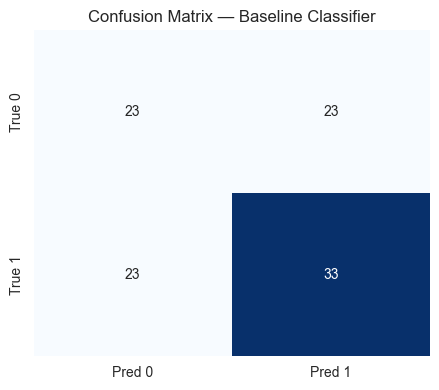

In [19]:
acc_test = accuracy_score(yc_test, clf_pred)
acc_train = accuracy_score(yc_train, clf_model.predict(Xc_train))
prec = precision_score(yc_test, clf_pred)
rec = recall_score(yc_test, clf_pred)
f1 = f1_score(yc_test, clf_pred)

print(f"Accuracy (test)  : {acc_test:.4f}")
print(f"Accuracy (train) : {acc_train:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification report:\n", classification_report(yc_test, clf_pred))

cm = confusion_matrix(yc_test, clf_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix — Baseline Classifier")
plt.tight_layout()
plt.show()

## 9. Visualize Both Trees

### Regression Tree

Root node split: Budget <= 37982.31
Full tree depth: 20
Total leaves: 379
Samples per leaf -> min: 1 | median: 1 | max: 7
Leaves with only 1 training sample: 360 out of 379


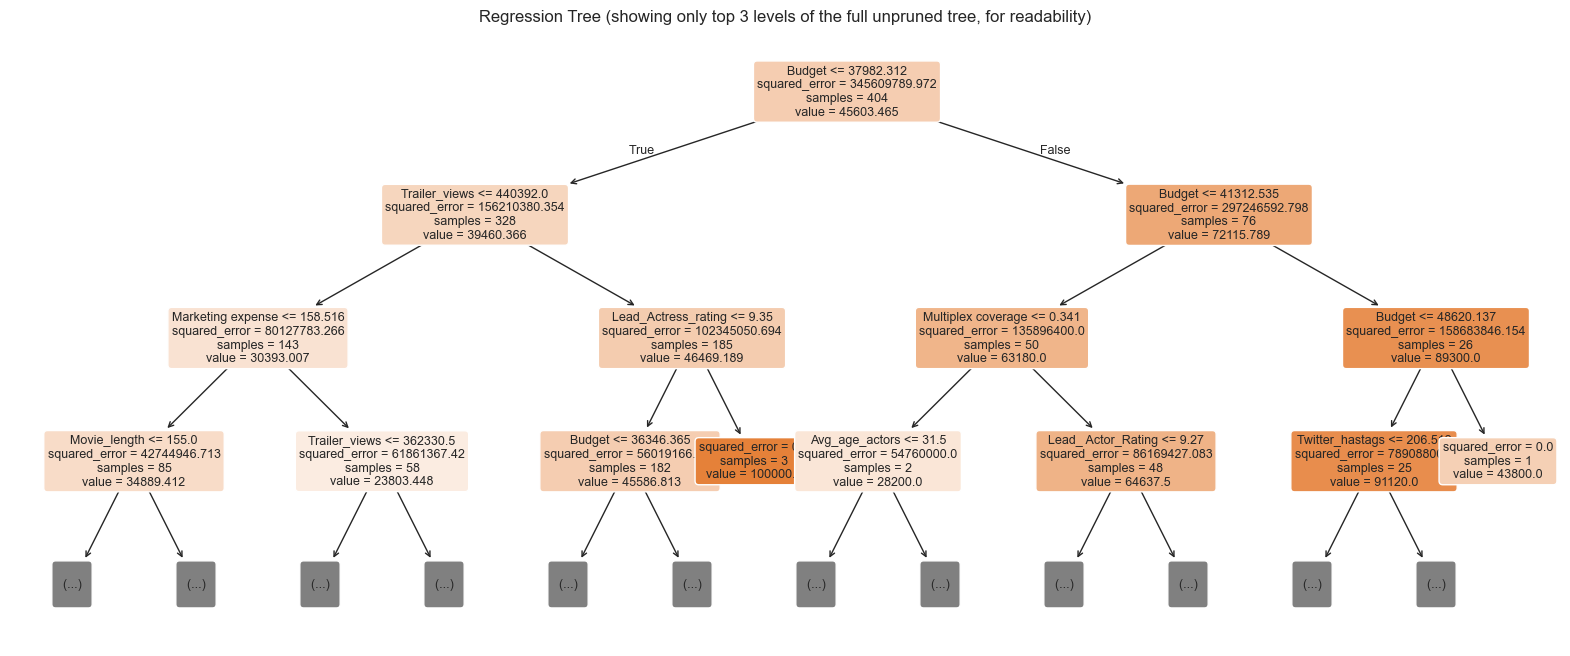

In [20]:
print("Root node split:", Xr_train.columns[reg_model.tree_.feature[0]], "<=", round(reg_model.tree_.threshold[0], 2))
print("Full tree depth:", reg_model.get_depth())
print("Total leaves:", reg_model.get_n_leaves())

leaf_mask = reg_model.tree_.children_left == -1
leaf_samples = reg_model.tree_.n_node_samples[leaf_mask]
print("Samples per leaf -> min:", leaf_samples.min(), "| median:", int(np.median(leaf_samples)), "| max:", leaf_samples.max())
print("Leaves with only 1 training sample:", (leaf_samples == 1).sum(), "out of", len(leaf_samples))

plt.figure(figsize=(20, 8))
plot_tree(reg_model, feature_names=Xr.columns, max_depth=3, filled=True, fontsize=9, rounded=True)
plt.title("Regression Tree (showing only top 3 levels of the full unpruned tree, for readability)")
plt.show()

### Classification Tree

Root node split: Collection <= 70300.0
Full tree depth: 14
Total leaves: 76
Samples per leaf -> min: 1 | median: 3 | max: 33
Leaves with only 1 training sample: 24 out of 76


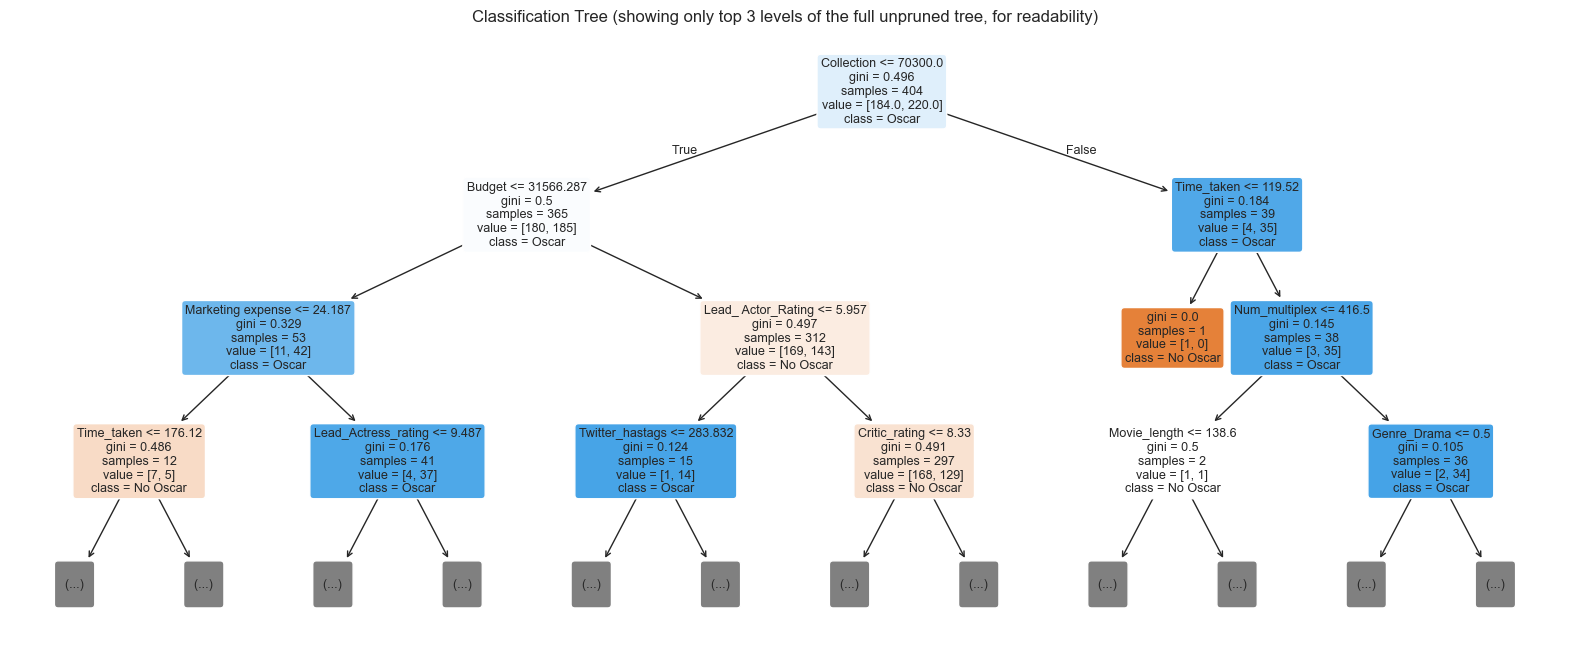

In [21]:
print("Root node split:", Xc_train.columns[clf_model.tree_.feature[0]], "<=", round(clf_model.tree_.threshold[0], 2))
print("Full tree depth:", clf_model.get_depth())
print("Total leaves:", clf_model.get_n_leaves())

leaf_mask_c = clf_model.tree_.children_left == -1
leaf_samples_c = clf_model.tree_.n_node_samples[leaf_mask_c]
print("Samples per leaf -> min:", leaf_samples_c.min(), "| median:", int(np.median(leaf_samples_c)), "| max:", leaf_samples_c.max())
print("Leaves with only 1 training sample:", (leaf_samples_c == 1).sum(), "out of", len(leaf_samples_c))

plt.figure(figsize=(20, 8))
plot_tree(clf_model, feature_names=Xc.columns, class_names=["No Oscar", "Oscar"], max_depth=3, filled=True, fontsize=9, rounded=True)
plt.title("Classification Tree (showing only top 3 levels of the full unpruned tree, for readability)")
plt.show()

## 10. Apply Pruning / Hyperparameter Tuning

We use `GridSearchCV` (5-fold cross-validation) to search over `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, and `ccp_alpha` simultaneously for both models.

In [22]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_leaf_nodes": [None, 15, 20, 30],
    "ccp_alpha": [0.0, 0.001, 0.01, 0.05],
}

grid_reg = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                         param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_reg.fit(Xr_train, yr_train)

print("Best regression params:", grid_reg.best_params_)
print("Best CV R2 (regression):", round(grid_reg.best_score_, 4))

Best regression params: {'ccp_alpha': 0.0, 'max_depth': 7, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV R2 (regression): 0.7512


In [23]:
grid_clf = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                         param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_clf.fit(Xc_train, yc_train)

print("Best classification params:", grid_clf.best_params_)
print("Best CV accuracy (classification):", round(grid_clf.best_score_, 4))

Best classification params: {'ccp_alpha': 0.01, 'max_depth': 7, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV accuracy (classification): 0.5967


## 11. Re-train Pruned Models and Compare

In [24]:
reg_pruned = grid_reg.best_estimator_
clf_pruned = grid_clf.best_estimator_

reg_pruned_pred_test = reg_pruned.predict(Xr_test)
reg_pruned_pred_train = reg_pruned.predict(Xr_train)
clf_pruned_pred_test = clf_pruned.predict(Xc_test)
clf_pruned_pred_train = clf_pruned.predict(Xc_train)

comparison = pd.DataFrame({
    "Model": [
        "Regression - Unpruned", "Regression - Pruned",
        "Classification - Unpruned", "Classification - Pruned",
    ],
    "Train Score": [
        r2_score(yr_train, reg_model.predict(Xr_train)),
        r2_score(yr_train, reg_pruned_pred_train),
        accuracy_score(yc_train, clf_model.predict(Xc_train)),
        accuracy_score(yc_train, clf_pruned_pred_train),
    ],
    "Test Score": [
        r2_score(yr_test, reg_pred),
        r2_score(yr_test, reg_pruned_pred_test),
        accuracy_score(yc_test, clf_pred),
        accuracy_score(yc_test, clf_pruned_pred_test),
    ],
    "Depth": [
        reg_model.get_depth(), reg_pruned.get_depth(),
        clf_model.get_depth(), clf_pruned.get_depth(),
    ],
    "Leaves": [
        reg_model.get_n_leaves(), reg_pruned.get_n_leaves(),
        clf_model.get_n_leaves(), clf_pruned.get_n_leaves(),
    ],
})
comparison["Train-Test Gap"] = comparison["Train Score"] - comparison["Test Score"]
display(comparison.round(4))

,Model,Train Score,Test Score,Depth,Leaves,Train-Test Gap
0,Regression - Unpruned,1.0000,0.8099,20,379,0.1901
1,Regression - Pruned,0.9436,0.8777,7,31,0.0659
2,Classification - Unpruned,1.0000,0.5490,14,76,0.4510
3,Classification - Pruned,0.7252,0.5784,7,10,0.1468


### 11.1 Pruned Tree Visualizations

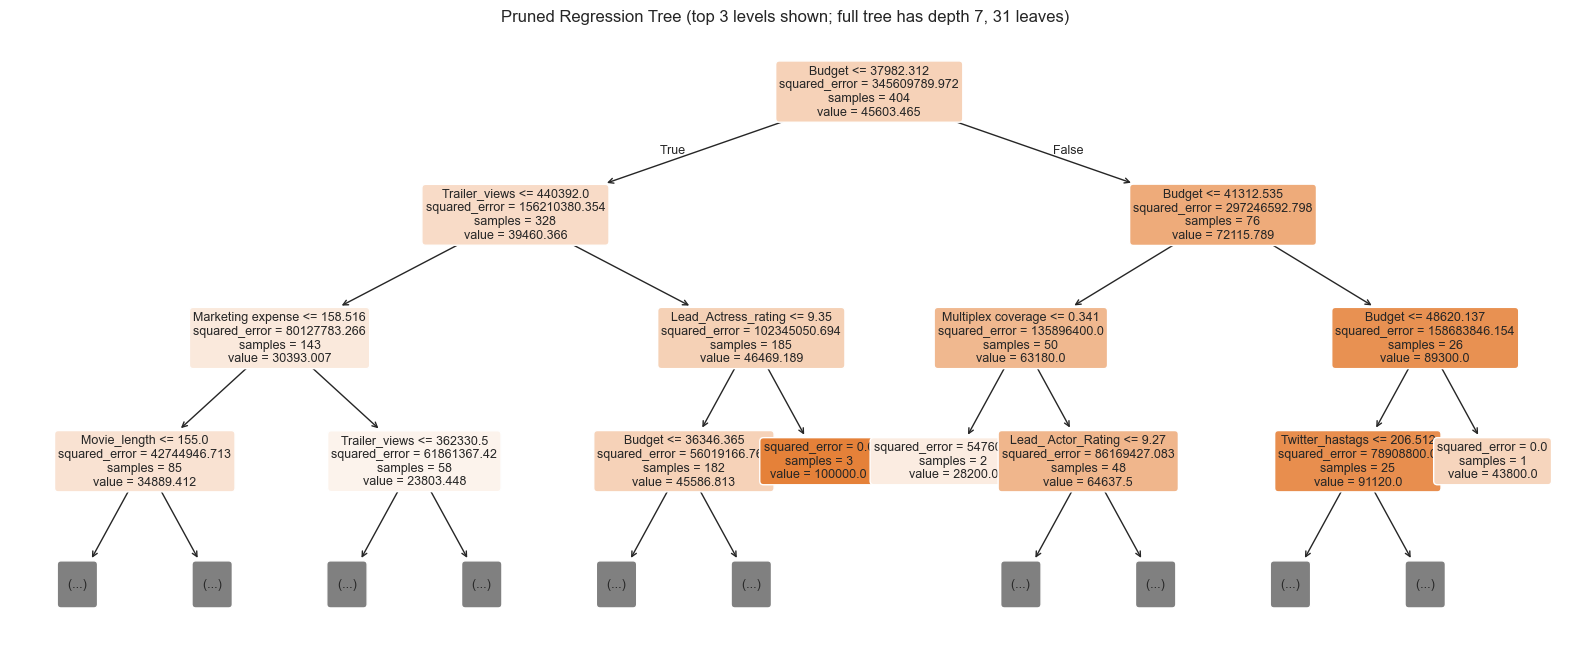

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(20, 8))
plot_tree(reg_pruned, feature_names=Xr.columns, max_depth=3, filled=True, fontsize=9, rounded=True)
plt.title("Pruned Regression Tree (top 3 levels shown; full tree has depth 7, 31 leaves)")
plt.show()

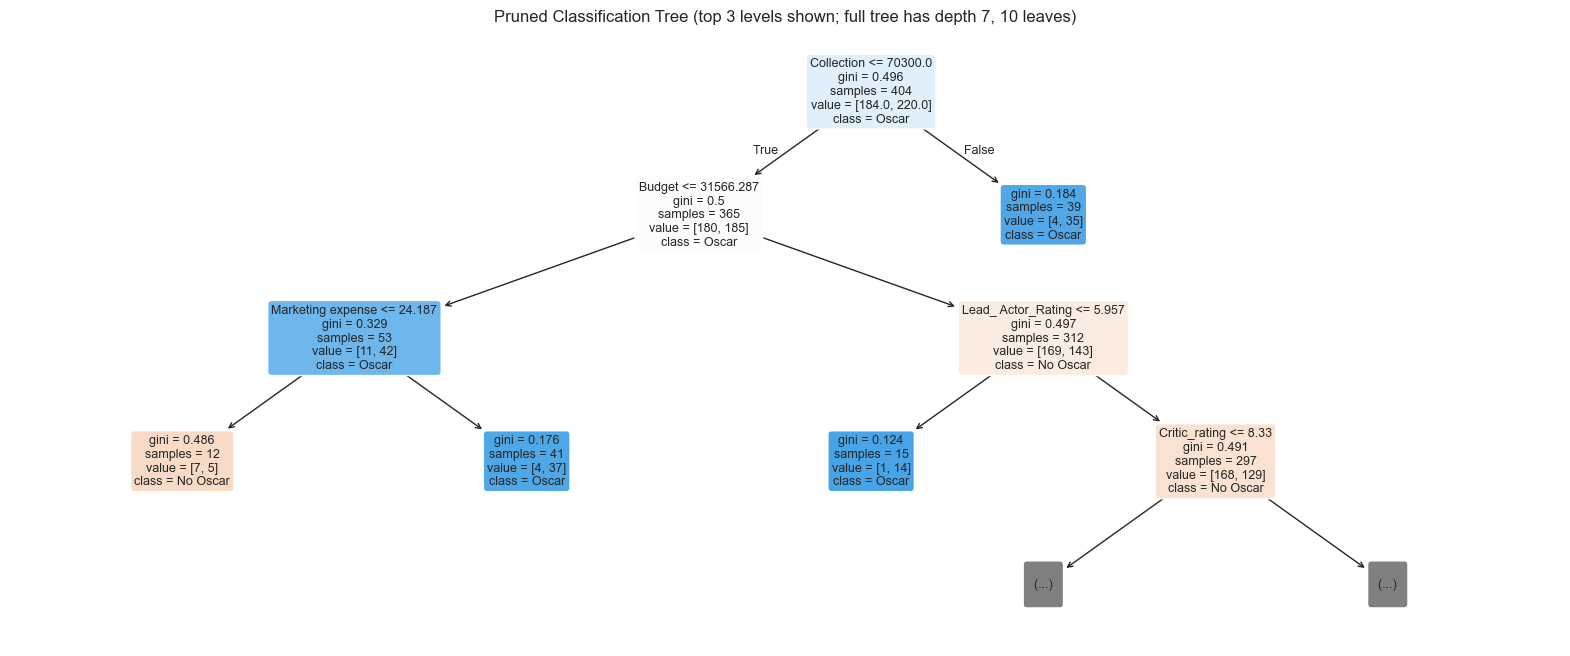

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(20, 8))
plot_tree(clf_pruned, feature_names=Xc.columns, class_names=["No Oscar", "Oscar"], max_depth=3, filled=True, fontsize=9, rounded=True)
plt.title("Pruned Classification Tree (top 3 levels shown; full tree has depth 7, 10 leaves)")
plt.show()

### 11.2 Feature Importance (Pruned Models)

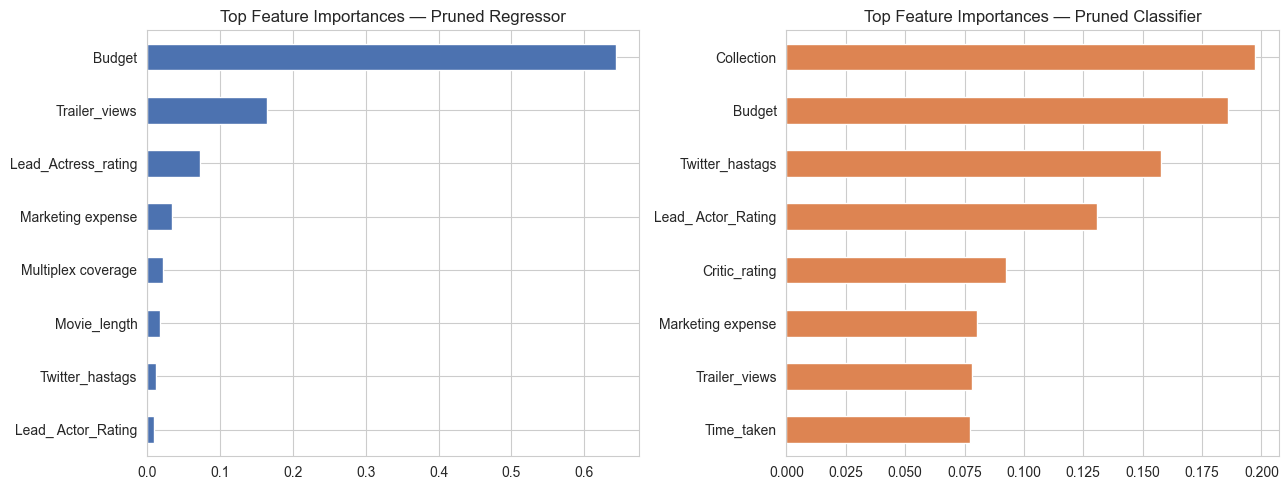

Top regression features:
 Budget                 0.643366
Trailer_views          0.164519
Lead_Actress_rating    0.072529
Marketing expense      0.033815
Multiplex coverage     0.021611
Movie_length           0.017613
Twitter_hastags        0.011963
Lead_ Actor_Rating     0.009693
dtype: float64

Top classification features:
 Collection            0.197444
Budget                0.185769
Twitter_hastags       0.157894
Lead_ Actor_Rating    0.130590
Critic_rating         0.092285
Marketing expense     0.080461
Trailer_views         0.078044
Time_taken            0.077513
dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_reg = pd.Series(reg_pruned.feature_importances_, index=Xr.columns).sort_values(ascending=False).head(8)
imp_reg.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Top Feature Importances — Pruned Regressor")

imp_clf = pd.Series(clf_pruned.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(8)
imp_clf.plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].invert_yaxis()
axes[1].set_title("Top Feature Importances — Pruned Classifier")

plt.tight_layout()
plt.show()

print("Top regression features:\n", imp_reg)
print("\nTop classification features:\n", imp_clf)

## 12. Final Insights

### Regression (predicting Collection)

- The important features are Budget and Trailer views. Production expense and Lead Actress rating are also important. This makes sense based on the correlation analysis and feature importance ranking.

- Pruning the tree helped improve generalization. The test R² score increased from 0.81 to 0.88. The gap between train and test scores decreased from 0.19 to 0.07. The tree also became much smaller from 379 leaves to 31 leaves.

- The unpruned tree was overfitting. It had a depth of 20 and a perfect train fit but a weaker test fit. The pruned tree has a depth of 7 and a better balance between bias and variance.

- The pruned regression tree is better for explanation. It is small enough to understand the logic from start to finish. The unpruned tree is too complex to interpret.

- The pruned tree is also better for prediction. It has a test error and a higher test R² score. This makes it better for predicting data.

### Classification (predicting Start Tech Oscar)

- The important features are spread out across variables. There is no dominant predictor. This is consistent with the correlations found in the data.

- Pruning the tree helped improve generalization. Only slightly. The test accuracy increased from 0.549 to 0.578. The tree became much smaller from 76 leaves to 10 leaves.

- The unpruned tree was overfitting. It had a train accuracy of 100%. A test accuracy near chance. The pruned tree still shows a gap between train and test accuracy suggesting some overfitting.

- The pruned classification tree is better for explanation. It is small enough to understand the logic behind the predictions.

- The pruned tree is also better for prediction. It has a test accuracy but the accuracy is still modest, around 0.58. This suggests that the dataset may need features or a different approach to improve prediction.

## Model Comparison Table (Summary)

In [28]:
summary = pd.DataFrame({
    "Metric": ["Train Score", "Test Score", "Tree Depth", "Number of Leaves"],
    "Regression - Unpruned": [
        round(r2_score(yr_train, reg_model.predict(Xr_train)), 4),
        round(r2_score(yr_test, reg_pred), 4),
        reg_model.get_depth(), reg_model.get_n_leaves(),
    ],
    "Regression - Pruned": [
        round(r2_score(yr_train, reg_pruned_pred_train), 4),
        round(r2_score(yr_test, reg_pruned_pred_test), 4),
        reg_pruned.get_depth(), reg_pruned.get_n_leaves(),
    ],
    "Classification - Unpruned": [
        round(accuracy_score(yc_train, clf_model.predict(Xc_train)), 4),
        round(accuracy_score(yc_test, clf_pred), 4),
        clf_model.get_depth(), clf_model.get_n_leaves(),
    ],
    "Classification - Pruned": [
        round(accuracy_score(yc_train, clf_pruned_pred_train), 4),
        round(accuracy_score(yc_test, clf_pruned_pred_test), 4),
        clf_pruned.get_depth(), clf_pruned.get_n_leaves(),
    ],
})
display(summary)

,Metric,Regression - Unpruned,Regression - Pruned,Classification - Unpruned,Classification - Pruned
0,Train Score,1.0000,0.9436,1.000,0.7252
1,Test Score,0.8099,0.8777,0.549,0.5784
2,Tree Depth,20.0000,7.0000,14.000,7.0000
3,Number of Leaves,379.0000,31.0000,76.000,10.0000


## Final

**Regression:** The Decision Tree does a good job of predicting Collection. It is mostly based on Budget and Trailer views. The tree that was not pruned was trying too hard to fit the data. Was picking up a lot of noise from the training data. This was causing it to have 379 leaves that were not really helping. We used GridSearchCV to find the way to limit the tree and this made it much smaller and more useful for predicting Collection. The new tree has a depth of 7 and 31 leaves. This makes it a lot better at explaining and predicting Collection.

**Classification:** The Decision Tree does not do a good job of predicting Start Tech Oscar. We already knew that none of the features were strongly connected to the target. So it is not surprising that even when we pruned the tree it still had trouble doing better, than guessing. Pruning did help to stop the tree from overfitting and made it a little easier to understand.. The real problem is that we do not have good enough features. To make the model better we would need to find features or create new ones. Just tweaking the tree algorithm will not be enough to make a difference.

In [45]:
## Questions and Answers from Live Class

	1.	What was the train score and test score for Decision Tree Regression? 
	2.	Was the training error much lower than the testing error? 
	3.	Did the tree become too deep? 
	4.	How many leaf nodes were created? 
	5.	Did you observe small leaves with very few samples? 
	6.	In the regression tree, which feature appeared near the root node? 
	7.	In the classification tree, which features appeared important? 
	8.	Did the unpruned tree look easy to explain to a business user? 
	9.	Was the model overfitting, underfitting, or generalizing well? 
	10.	What metric did you trust more: train score or test score? Why? 
	11.	If the tree is too deep, which hyperparameter can control it? 

	1.	If the tree has very small leaf nodes, which hyperparameter can control it? 
	2.	If we want only a limited number of business segments, which hyperparameter can control it? 


1. Train score was 1.0 (R²) and test score was about 0.81. So train was basically perfect.
2. Yes, training error was much lower than testing error. Train R² = 1.0 (zero error) but test R² was only 0.81, so there's a clear gap.
3. Yes, the tree went way too deep — depth 20.
4. It created 379 leaf nodes.
5. Yes, a lot of tiny leaves. Out of 379 leaves, 360 of them had just 1 sample in them. That's basically the tree memorizing single rows instead of learning a pattern.
6. Budget appeared right at the root node. Makes sense since it also had the strongest correlation with Collection in the EDA.
7. For the classification tree, Collection, Budget, Twitter_hastags, and Lead_Actor_Rating came out as the most important features. But none of them were super dominant — importance was pretty spread out, which matches how weak the correlations were in EDA.
8. No, not really. With 379 leaves you can't trace the logic by eye, so a business person would just see a huge messy tree, not something explainable.
9. Overfitting. Train score near perfect, test score noticeably worse — classic overfitting signal.
10. Test score, because train score can lie to you. A model can just memorize the training data and look perfect there, but test score tells you how it actually performs on data it hasn't seen, which is what matters in the real world.
11. max_depth controls how deep the tree can grow.
For the second set:
1. min_samples_leaf — this stops the tree from making leaves with very few (like 1) samples.
2. max_leaf_nodes — this directly caps how many final leaves (segments) the tree can end up with, so it's the right one if you want only a limited number of business segments.